# Contrastive Divergence Algorithm

In [5]:
# Check for all needed packages
import numpy
import matplotlib
import mnists
# In case of ImportError, install them to the running kernel with
# %pip install numpy matplotlib mnists
# or the the runtime container with:
# !pip install numpy matplotlib mnists
# (In case of the latter, remember to restart the kernel!)

In [6]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1234)

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams["figure.figsize"] = [16, 9]

### Handy utility functions

In [7]:
def append_ones(matrix: np.ndarray) -> np.ndarray:
    """
    Appends a column of ones to the right side of a 2D matrix.
    """
    return np.concatenate((matrix, np.ones((matrix.shape[0], 1), dtype=np.float32)), axis=1)


def zeros(*dims: int) -> np.ndarray:
    """
    Creates a NumPy array of zeros with the given shape.

    Args:
        *dims:  Variable number of integers defining the shape of the array.
                E.g. zeros(3, 4) creates a (3, 4) array.
    """
    return np.zeros(shape=tuple(dims), dtype=np.float32)
def ones(*dims: int) -> np.ndarray:
    """
    Creates a NumPy array of ones with the given shape.

    Args:
        *dims:  Variable number of integers defining the shape of the array.
                E.g. ones(3, 4) creates a (3, 4) array.
    """
    return np.ones(shape=tuple(dims), dtype=np.float32)

def rand(*dims: int) -> np.ndarray:
    """
    Creates a NumPy array of random values sampled from a uniform [0, 1) distribution.

    Args:
        *dims:  Variable number of integers defining the shape of the array.
                E.g. rand(3, 4) creates a (3, 4) array.
    """
    return np.random.rand(*dims).astype(np.float32)

def chunks(seq: list, size: int) -> tuple[np.ndarray]:
    """
    Splits a sequence into consecutive chunks of a given size.

    The last chunk may be smaller than `size` if the sequence length
    is not evenly divisible.

    Args:
        seq:  The input sequence (e.g. list or other sliceable) to split.
        size: The maximum number of elements in each chunk.

    Returns:
        Successive sub-sequences of length `size` (or less for the final chunk).
    """
    return tuple([seq[pos:(pos + size)] for pos in range(0, len(seq), size)])

def arrange_tiles_img(examples: np.ndarray) -> np.ndarray:
    """
    Arrange 2D matrices as tiles

    Takes 4D `examples` tensor with dims:
        rows x cols x tile_height x tile_width
    """
    rows_count = examples.shape[0]
    cols_count = examples.shape[1]
    tile_height = examples.shape[2]
    tile_width = examples.shape[3]

    space_between_tiles = 2
    img_matrix = np.empty(shape=(rows_count * (tile_height + space_between_tiles) - space_between_tiles,
                                 cols_count * (tile_width + space_between_tiles) - space_between_tiles))
    img_matrix.fill(np.nan)

    for r in range(rows_count):
        for c in range(cols_count):
            x_0 = r * (tile_height + space_between_tiles)
            y_0 = c * (tile_width + space_between_tiles)
            img_matrix[x_0:x_0 + tile_height, y_0:y_0 + tile_width] = examples[r, c]

    return img_matrix

def preview_tiles(examples: np.ndarray) -> np.ndarray:
    """Previews the arrange tiles"""
    img = arrange_tiles_img(examples)
    plt.matshow(img, cmap='gray', interpolation='none')
    plt.axis('off')
    plt.show()

# MNIST dataset

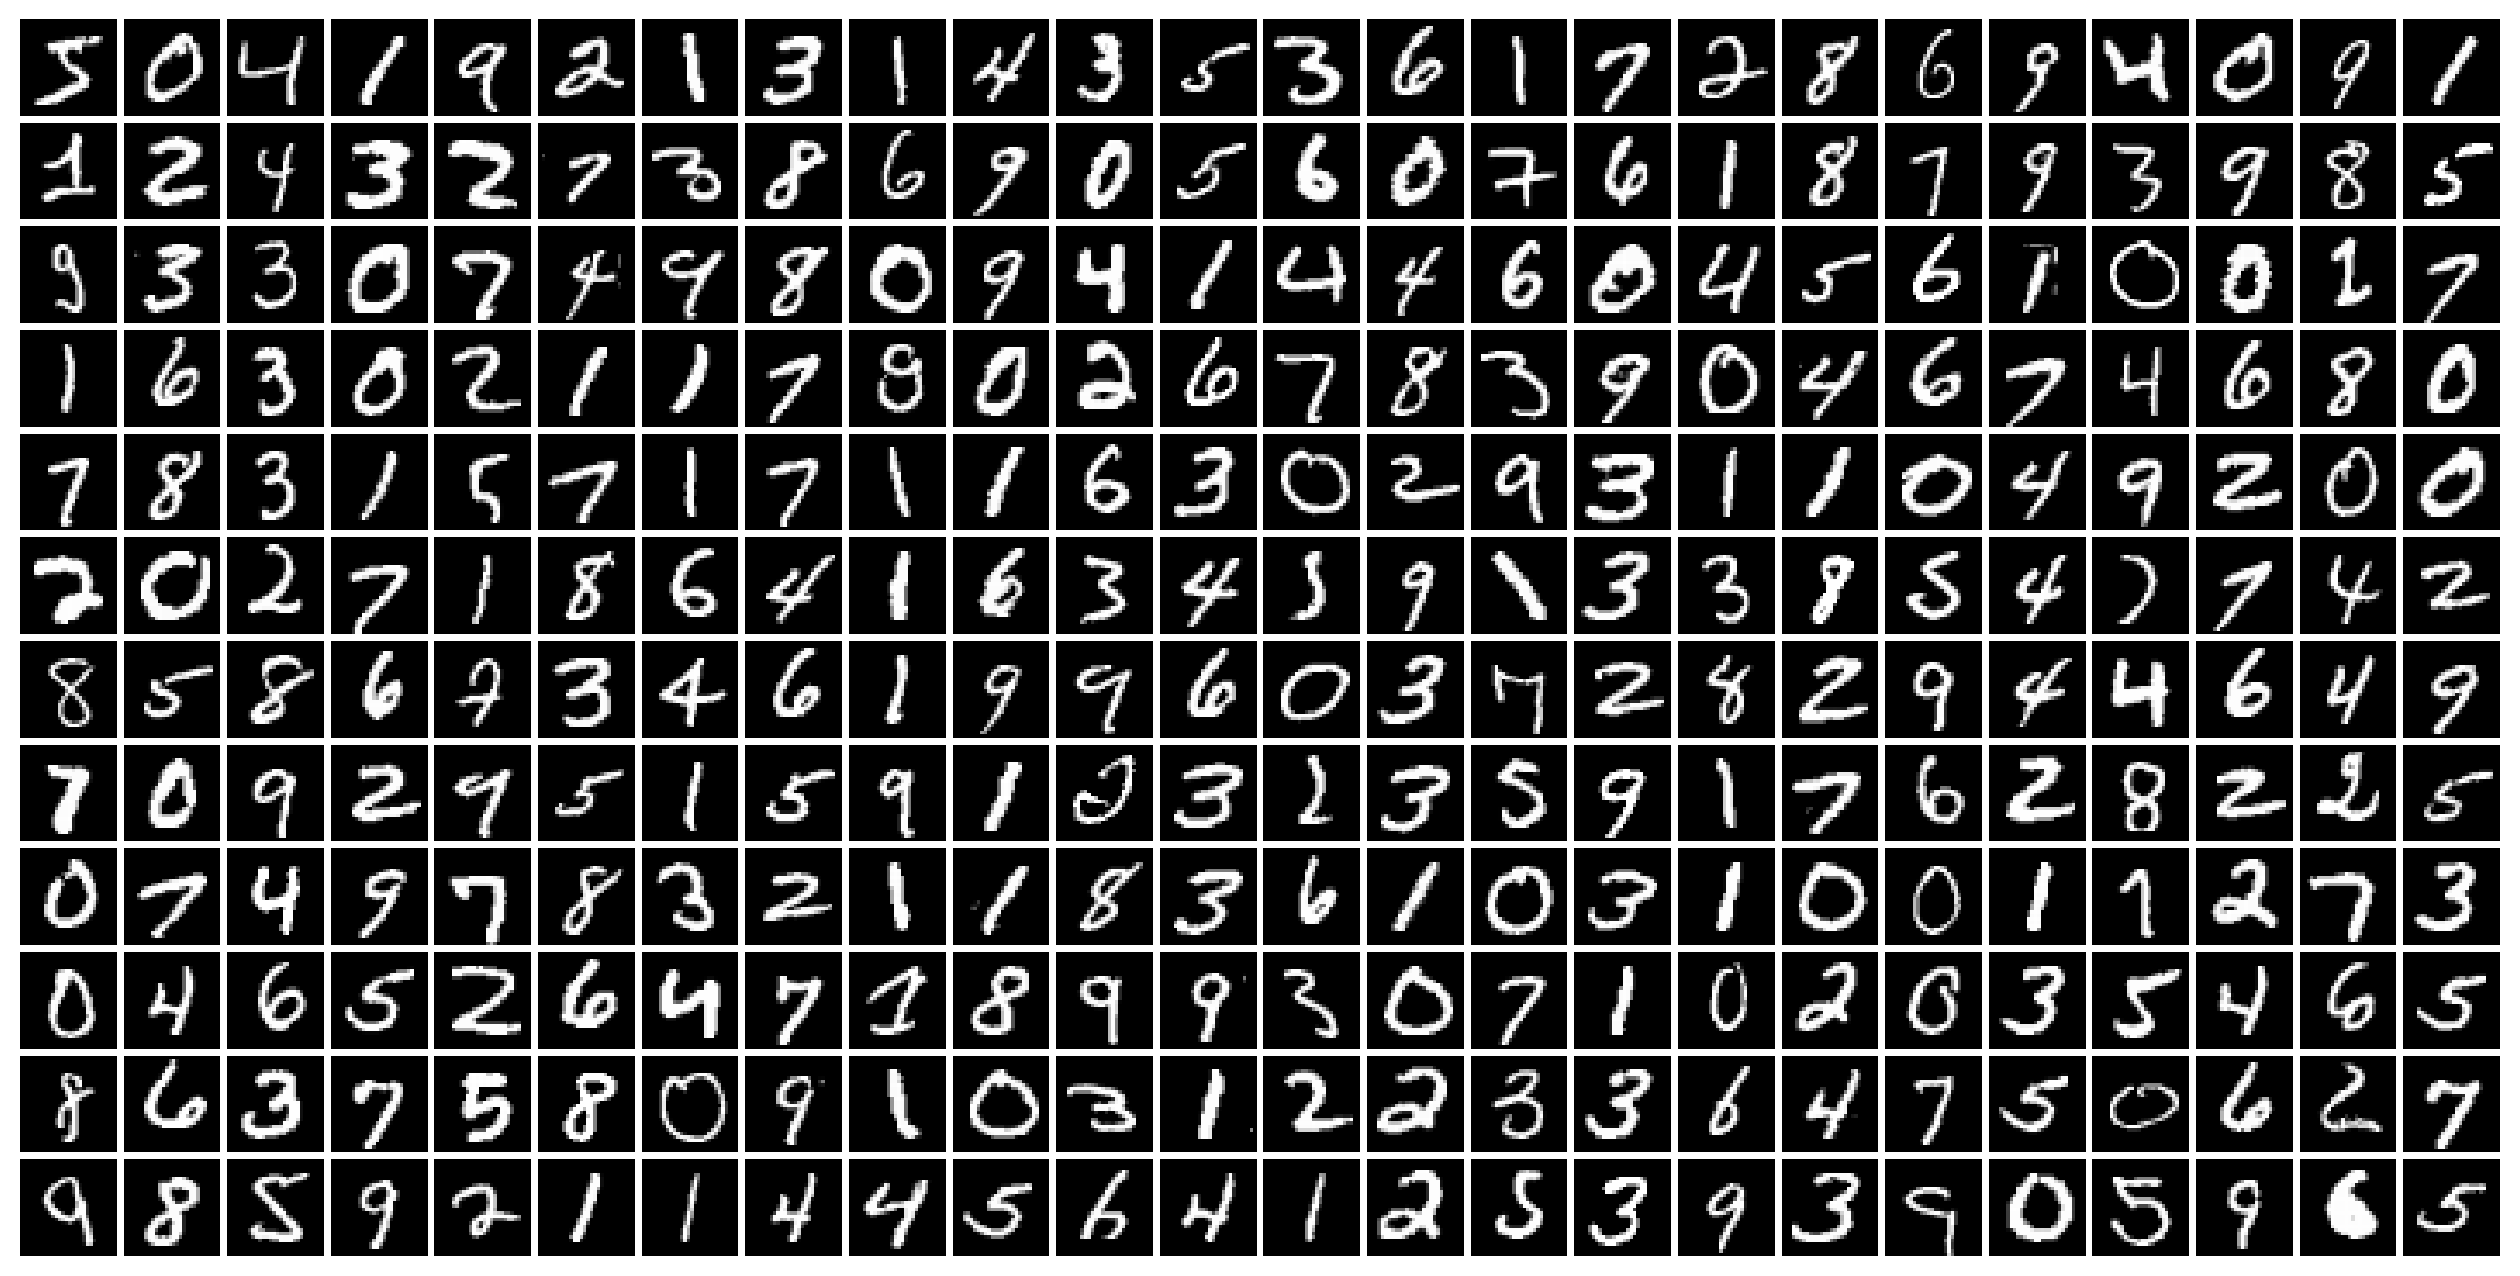

In [8]:
from mnists import MNIST
mnist = MNIST()

def create_mnist_digits() -> np.ndarray:
    n_rows = 12
    n_cols = 24
    tile_dim = 28 # [px]
    shape = (n_rows, n_cols, tile_dim, tile_dim)
    return np.reshape(mnist.train_images()[:12*24], newshape=shape)

mnist_digits = create_mnist_digits()

preview_tiles(mnist_digits)

# Restricted Boltzmann Machine & Contrastive Divergence algorithm

In [9]:
def sigmoid(x: np.ndarray) -> np.ndarray:
    """
    Applies the sigmoid (logistic) activation function element-wise.

    Squashes each value in `x` to the range (0, 1), which is
    interpreted as an activation probability in the RBM context.
    """
    return 1.0 / (1.0 + np.exp(-x))

class RestrictedBoltzmanMachine:
    """
    A Restricted Boltzmann Machine (RBM) with a single visible and hidden layer.

    The weight matrix W has shape (visible_size + 1, hidden_size + 1), where
    the extra row and column are reserved for bias units.

    Attributes:
        visible_size:  Number of visible (input) units, excluding the bias.
        hidden_size:   Number of hidden units, excluding the bias.
        learning_rate: Step size used during contrastive divergence updates.
        W:             Weight matrix of shape (visible_size+1, hidden_size+1).
    """

    def __init__(
        self,
        visible_size: int,
        hidden_size: int,
        learning_rate: float
    ):
        self.visible_size = visible_size
        self.hidden_size = hidden_size
        self.learning_rate = learning_rate

        self.reset()

    def reset(self) -> None:
        self.W = np.random.normal(
            scale=0.01,
            size=(self.visible_size + 1, self.hidden_size + 1),
        ).astype(np.float32)

        self.W[:, -1] = 0.0   # zero hidden-bias weights
        self.W[-1, :] = 0.0   # zero visible-bias weights

## Algorithm description

### [PL] Opis algorytmu Contrastive Divergence (CD-k)

W sieci RBM gradient funkcji kosztu względem wag wyznaczamy zgodnie ze wzorem:

$$
-\frac{\partial}{\partial w_{ij}} \log P(\mathbf{v})
= -\mathbb{E}[v_i h_j \mid \mathbf{v}] + \mathbb{E}[v_i h_j]
$$

#### Faza pozytywna — odpowiada za część $\mathbb{E}[v_i h_j \mid \mathbf{v}]$

Tę część gradientu wyznaczamy przez wyliczenie iloczynów $v_i h_j$ pomiędzy elementami wektora obserwacji ($v_i$) a prawdopodobieństwami aktywacji w warstwie ukrytej ($h_j$). Operację tę możemy zapisać w postaci zwektoryzowanej jako:

$$
\nabla_P = \mathbf{v}^T \sigma(\mathbf{v} W)
$$

#### Faza negatywna — odpowiada za część $\mathbb{E}[v_i h_j]$

Rozpoczynamy od prawdopodobieństw aktywacji neuronów w warstwie ukrytej, które zostały wyznaczone w fazie pozytywnej. Na ich podstawie losujemy próbkę aktywacji w warstwie ukrytej:

$$
\mathbf{h} \sim \text{Bernoulli}(\sigma(\mathbf{v} W))
$$

Następnie losujemy próbkę aktywacji w warstwie widocznej:

$$
\mathbf{v}_1 \sim \text{Bernoulli}(\sigma(\mathbf{h} W^T))
$$

Aby wyznaczyć *fantazję* sieci RBM, powyższe próbki losujemy (naprzemiennie) $k$ razy (gdzie $k$ to parametr algorytmu CD-$k$):

$$
\mathbf{h}_{k-1} \sim \text{Bernoulli}(\sigma(\mathbf{v}_{k-1} W))
$$

$$
\mathbf{v}_k \sim \text{Bernoulli}(\sigma(\mathbf{h}_{k-1} W^T))
$$

Część negatywną gradientu wyznaczamy poprzez wyliczenie iloczynów $v_{k,i} h_j$ pomiędzy elementami wektora *fantazji* RBM a prawdopodobieństwami aktywacji w warstwie ukrytej wyliczonymi dla tej *fantazji*. Operację tę możemy zapisać w postaci zwektoryzowanej jako:

$$
\nabla_N = \mathbf{v}_k^T \sigma(\mathbf{v}_k W)
$$

#### Aktualizacja macierzy wag RBM

Uczymy stochastycznym spadkiem wzdłuż gradientu:

$$
\phi_{t+1} = \phi_t - \epsilon \nabla
$$

co dla gradientu RBM daje:

$$
W_{t+1} = W_t + \epsilon \nabla_P - \epsilon \nabla_N
$$

## CK-d implementation

In [10]:
# def contrastive_divergence_update(rbm: RestrictedBoltzmanMachine, minibatch: np.ndarray, k: int = 1) -> None:
#     """
#     Performs a single Contrastive Divergence (CD-k) weight update in-place.

#     CD-k approximates the log-likelihood gradient by running k steps of
#     Gibbs sampling starting from the training data.  The resulting
#     positive and negative phase statistics are used to update weights rbm.W.

#     All visible and hidden arrays carry an appended bias column (via
#     `append_ones`), so matrix multiplications automatically include biases.

#     Args:
#         rbm:        The RBM whose weights will be updated.
#         minibatch:  A 2D float32 array of shape (n, visible_size + 1),
#                     where the last column is the bias (all ones).
#         k:          Number of Gibbs sampling steps (default 1, i.e. CD-1).
#     """
#     observations_count = minibatch.shape[0]

#     # ---- Positive phase: clamp visible units to data ----
#     positive_visible = minibatch
#     negative_visible = append_ones(zeros(observations_count, rbm.visible_size))

#     # ---- Negative phase: initialise with a stochastic hidden sample ----
#     positive_hidden = append_ones(zeros(observations_count, rbm.hidden_size))
#     negative_hidden = append_ones(zeros(observations_count, rbm.hidden_size))

#     positive_hidden = sigmoid(positive_visible @ rbm.W)

#     positive_grad = positive_visible.T @ positive_hidden
#     positive_grad = positive_grad / observations_count

#     negative_hidden = (positive_hidden > rand(*positive_hidden.shape)).astype(np.float32)

#     for _ in range(k):
#         negative_visible = sigmoid(negative_hidden @ rbm.W.T)
#         negative_visible = (negative_visible > rand(*negative_visible.shape)).astype(np.float32)

#         negative_hidden = sigmoid(negative_visible @ rbm.W)
#         negative_hidden = (negative_hidden > rand(*negative_hidden.shape)).astype(np.float32)
#     #

#     negative_grad = negative_visible.T @ sigmoid(negative_visible @ rbm.W)
#     negative_grad = negative_grad / observations_count
#     rbm.W = rbm.W + rbm.learning_rate * positive_grad - rbm.learning_rate * negative_grad

In [11]:
def contrastive_divergence_update(rbm: RestrictedBoltzmanMachine, minibatch: np.ndarray, k: int = 1) -> None:
    """
    Performs a single Contrastive Divergence (CD-k) weight update in-place.

    CD-k approximates the log-likelihood gradient by running k steps of
    Gibbs sampling starting from the training data.  The resulting
    positive and negative phase statistics are used to update weights rbm.W.

    All visible and hidden arrays carry an appended bias column (via
    `append_ones`), so matrix multiplications automatically include biases.

    Args:
        rbm:        The RBM whose weights will be updated.
        minibatch:  A 2D float32 array of shape (n, visible_size + 1),
                    where the last column is the bias (all ones).
        k:          Number of Gibbs sampling steps (default 1, i.e. CD-1).
    """
    observations_count = minibatch.shape[0]

    positive_visible = minibatch
    negative_visible = append_ones(zeros(observations_count, rbm.visible_size))

    positive_hidden = append_ones(zeros(observations_count, rbm.hidden_size))
    negative_hidden = append_ones(zeros(observations_count, rbm.hidden_size))

    positive_hidden[:, :-1] = sigmoid(minibatch @ rbm.W[:, :-1])
    negative_hidden[:, :-1] = (positive_hidden[:, :-1] > rand(observations_count, rbm.hidden_size)).astype(np.float32)

    for cd_i in range(k):
        negative_visible[:, :-1] = sigmoid(negative_hidden @ np.transpose(rbm.W[:-1, :]))
        negative_visible[:, :-1] = (negative_visible[:, :-1] > rand(observations_count, rbm.visible_size)).astype(np.float32)

        negative_hidden[:, :-1] = sigmoid(negative_visible @ rbm.W[:, :-1])
        if cd_i < (k - 1):
            negative_hidden[:, :-1] = (negative_hidden[:, :-1] > rand(observations_count, rbm.hidden_size)).astype(np.float32)
    #

    rbm.W += (rbm.learning_rate / observations_count) * (np.transpose(positive_visible) @ positive_hidden)
    rbm.W -= (rbm.learning_rate / observations_count) * (np.transpose(negative_visible) @ negative_hidden)
#

### RBM reconstruction error

In [12]:
def reconstruction_error(rbm: RestrictedBoltzmanMachine, minibatch: np.ndarray) -> float:
    """
    Computes the mean per-sample reconstruction error on a minibatch.

    Runs a single forward-backward pass (encode then decode) without
    weight updates and returns the average squared difference between
    the original visible units and their reconstructions.

    Args:
        rbm:        The trained (or partially trained) RBM.
        minibatch:  A 2D float32 array of shape (n, visible_size + 1),
                    with the bias column appended.

    Returns:
        A scalar float: sum of squared errors divided by the number
        of observations.
    """
    observations_count = minibatch.shape[0]
    visible = zeros(observations_count, rbm.visible_size)
    hidden = append_ones(zeros(observations_count, rbm.hidden_size))

    hidden = sigmoid(minibatch @ rbm.W)
    visible = sigmoid(hidden @ rbm.W.T)

    return np.mean((minibatch - visible) ** 2)
#

# RBM Training

In [13]:
import time

DATASET_SIZE: int = 20000 # 60000 for whole dataset
DIGIT_SIZE: int = 28

VISIBLE_LAYER_SIZE: int = DIGIT_SIZE*DIGIT_SIZE
HIDDEN_LAYER_SIZE: int = 128
LEARNING_RATE: float = 0.1

mnist_train = mnist.train_images().astype(np.float32) / 255.0

np.random.shuffle(mnist_train)
dataset = np.reshape(mnist_train[:DATASET_SIZE], newshape=(DATASET_SIZE, DIGIT_SIZE*DIGIT_SIZE))
dataset = append_ones(dataset)

monitoring_indeces = np.random.choice(DATASET_SIZE, 256, replace=False)
monitoring_set = dataset[monitoring_indeces]

rbm_model = RestrictedBoltzmanMachine(VISIBLE_LAYER_SIZE, HIDDEN_LAYER_SIZE, LEARNING_RATE)

In [14]:
def draw_filters(rbm: RestrictedBoltzmanMachine) -> None:
    """
    Visualises the learned RBM weight filters as a grid of 28×28 tiles.

    Transposes W, strips the bias row/column, reshapes the hidden-unit
    weight vectors into 28×28 images, clips extreme values to [-1, 1],
    and renders them using `tiles`.

    Args:
        rbm: A trained RBM whose W has shape (visible_size+1, hidden_size+1).
    """
    filters: np.ndarray = np.reshape(
        np.transpose(rbm.W)[:-1, :-1],
        newshape=(8, -1, 28, 28),
    )
    filters = np.clip(filters, -1, 1)
    preview_tiles(filters)

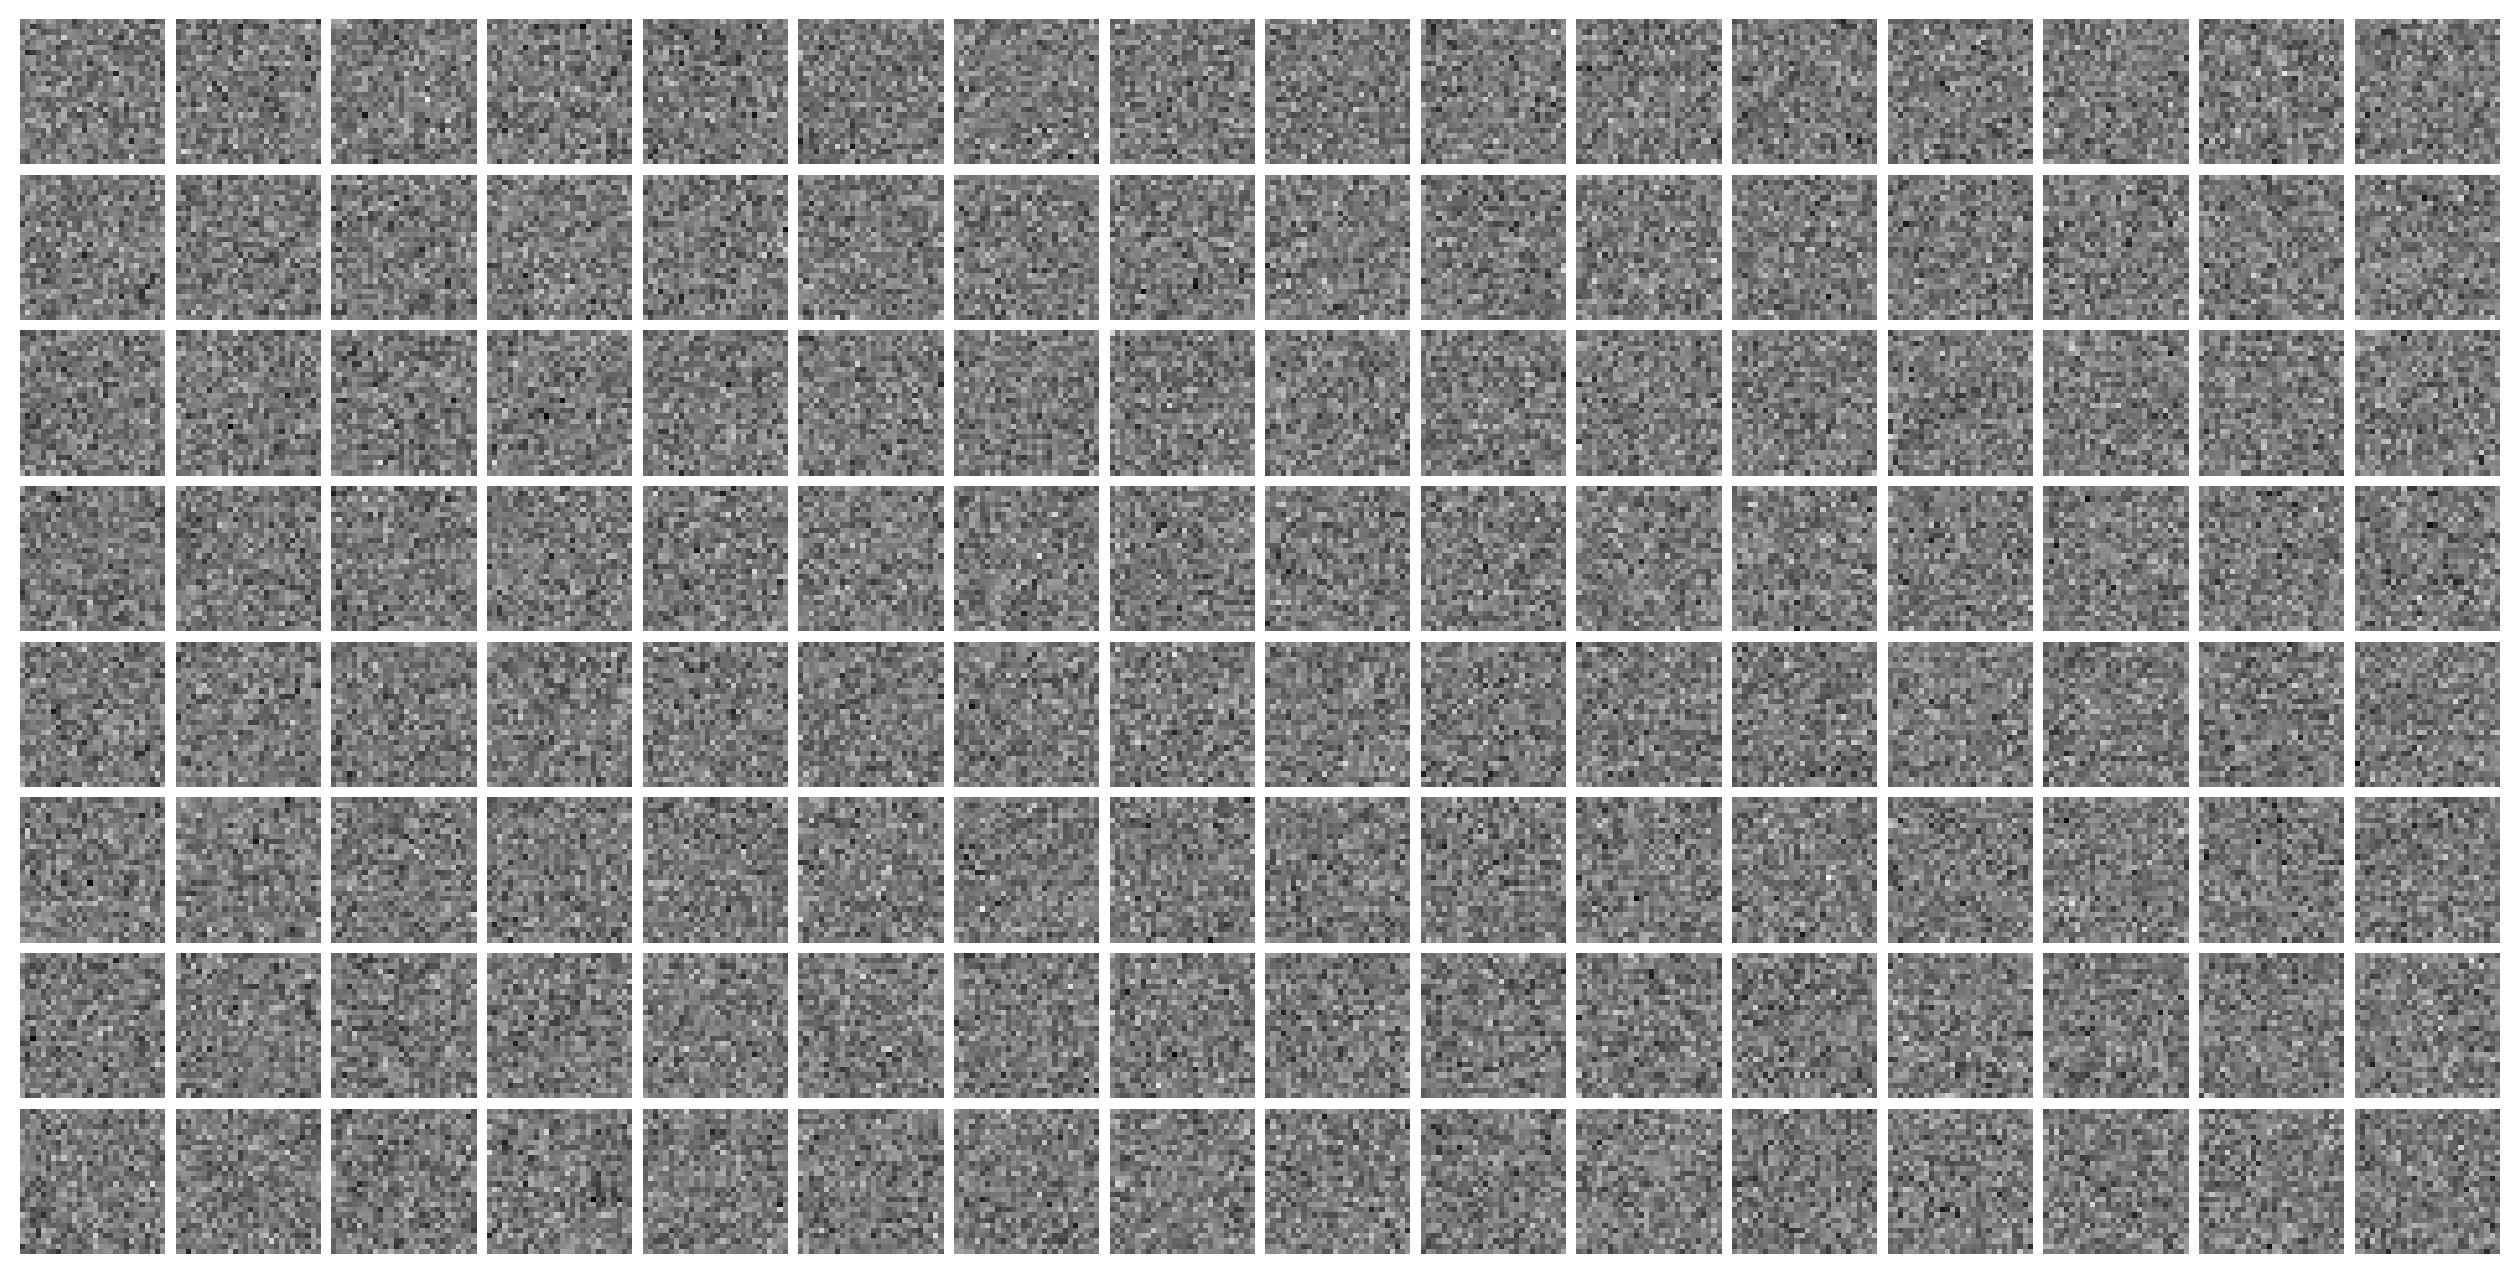

In [15]:
draw_filters(rbm_model)

In [16]:
rbm_model.W.shape

(785, 129)

In [17]:
BATCH_SIZE: int = 128
EPOCHS_COUNT: int = 25

def train_epoch(rbm: RestrictedBoltzmanMachine, dataset: np.ndarray) -> None:
    batches_limit = dataset.shape[0] / BATCH_SIZE
    for batch_idx, batch in enumerate(chunks(dataset, BATCH_SIZE)):
        contrastive_divergence_update(rbm, batch)
        if batch_idx % round(batches_limit / 50) == 0: print("#", end="")

rbm_model.reset()
for epoch in range(EPOCHS_COUNT):
    print(f"Epoch {epoch + 1}: \t")

    start_time = time.time()
    train_epoch(rbm_model, dataset)

    elapsed = time.time() - start_time
    error = reconstruction_error(rbm_model, monitoring_set)
    print(f"\telapsed: {elapsed:>2.2f}s, reconstruction error: {error:>2.2f}")

print("Training finished!")

Epoch 1: 	
#####################################################

C:\Users\Filip\AppData\Local\Temp\ipykernel_5196\1628241164.py:8: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-x))


	elapsed: 0.71s, reconstruction error: 0.04
Epoch 2: 	
#####################################################	elapsed: 0.49s, reconstruction error: 0.03
Epoch 3: 	
#####################################################	elapsed: 0.49s, reconstruction error: 0.03
Epoch 4: 	
#####################################################	elapsed: 0.48s, reconstruction error: 0.03
Epoch 5: 	
#####################################################	elapsed: 0.57s, reconstruction error: 0.03
Epoch 6: 	
#####################################################	elapsed: 0.50s, reconstruction error: 0.02
Epoch 7: 	
#####################################################	elapsed: 0.48s, reconstruction error: 0.02
Epoch 8: 	
#####################################################	elapsed: 0.47s, reconstruction error: 0.02
Epoch 9: 	
#####################################################	elapsed: 0.55s, reconstruction error: 0.02
Epoch 10: 	
#####################################################	elapsed: 0.56s, reconstruc

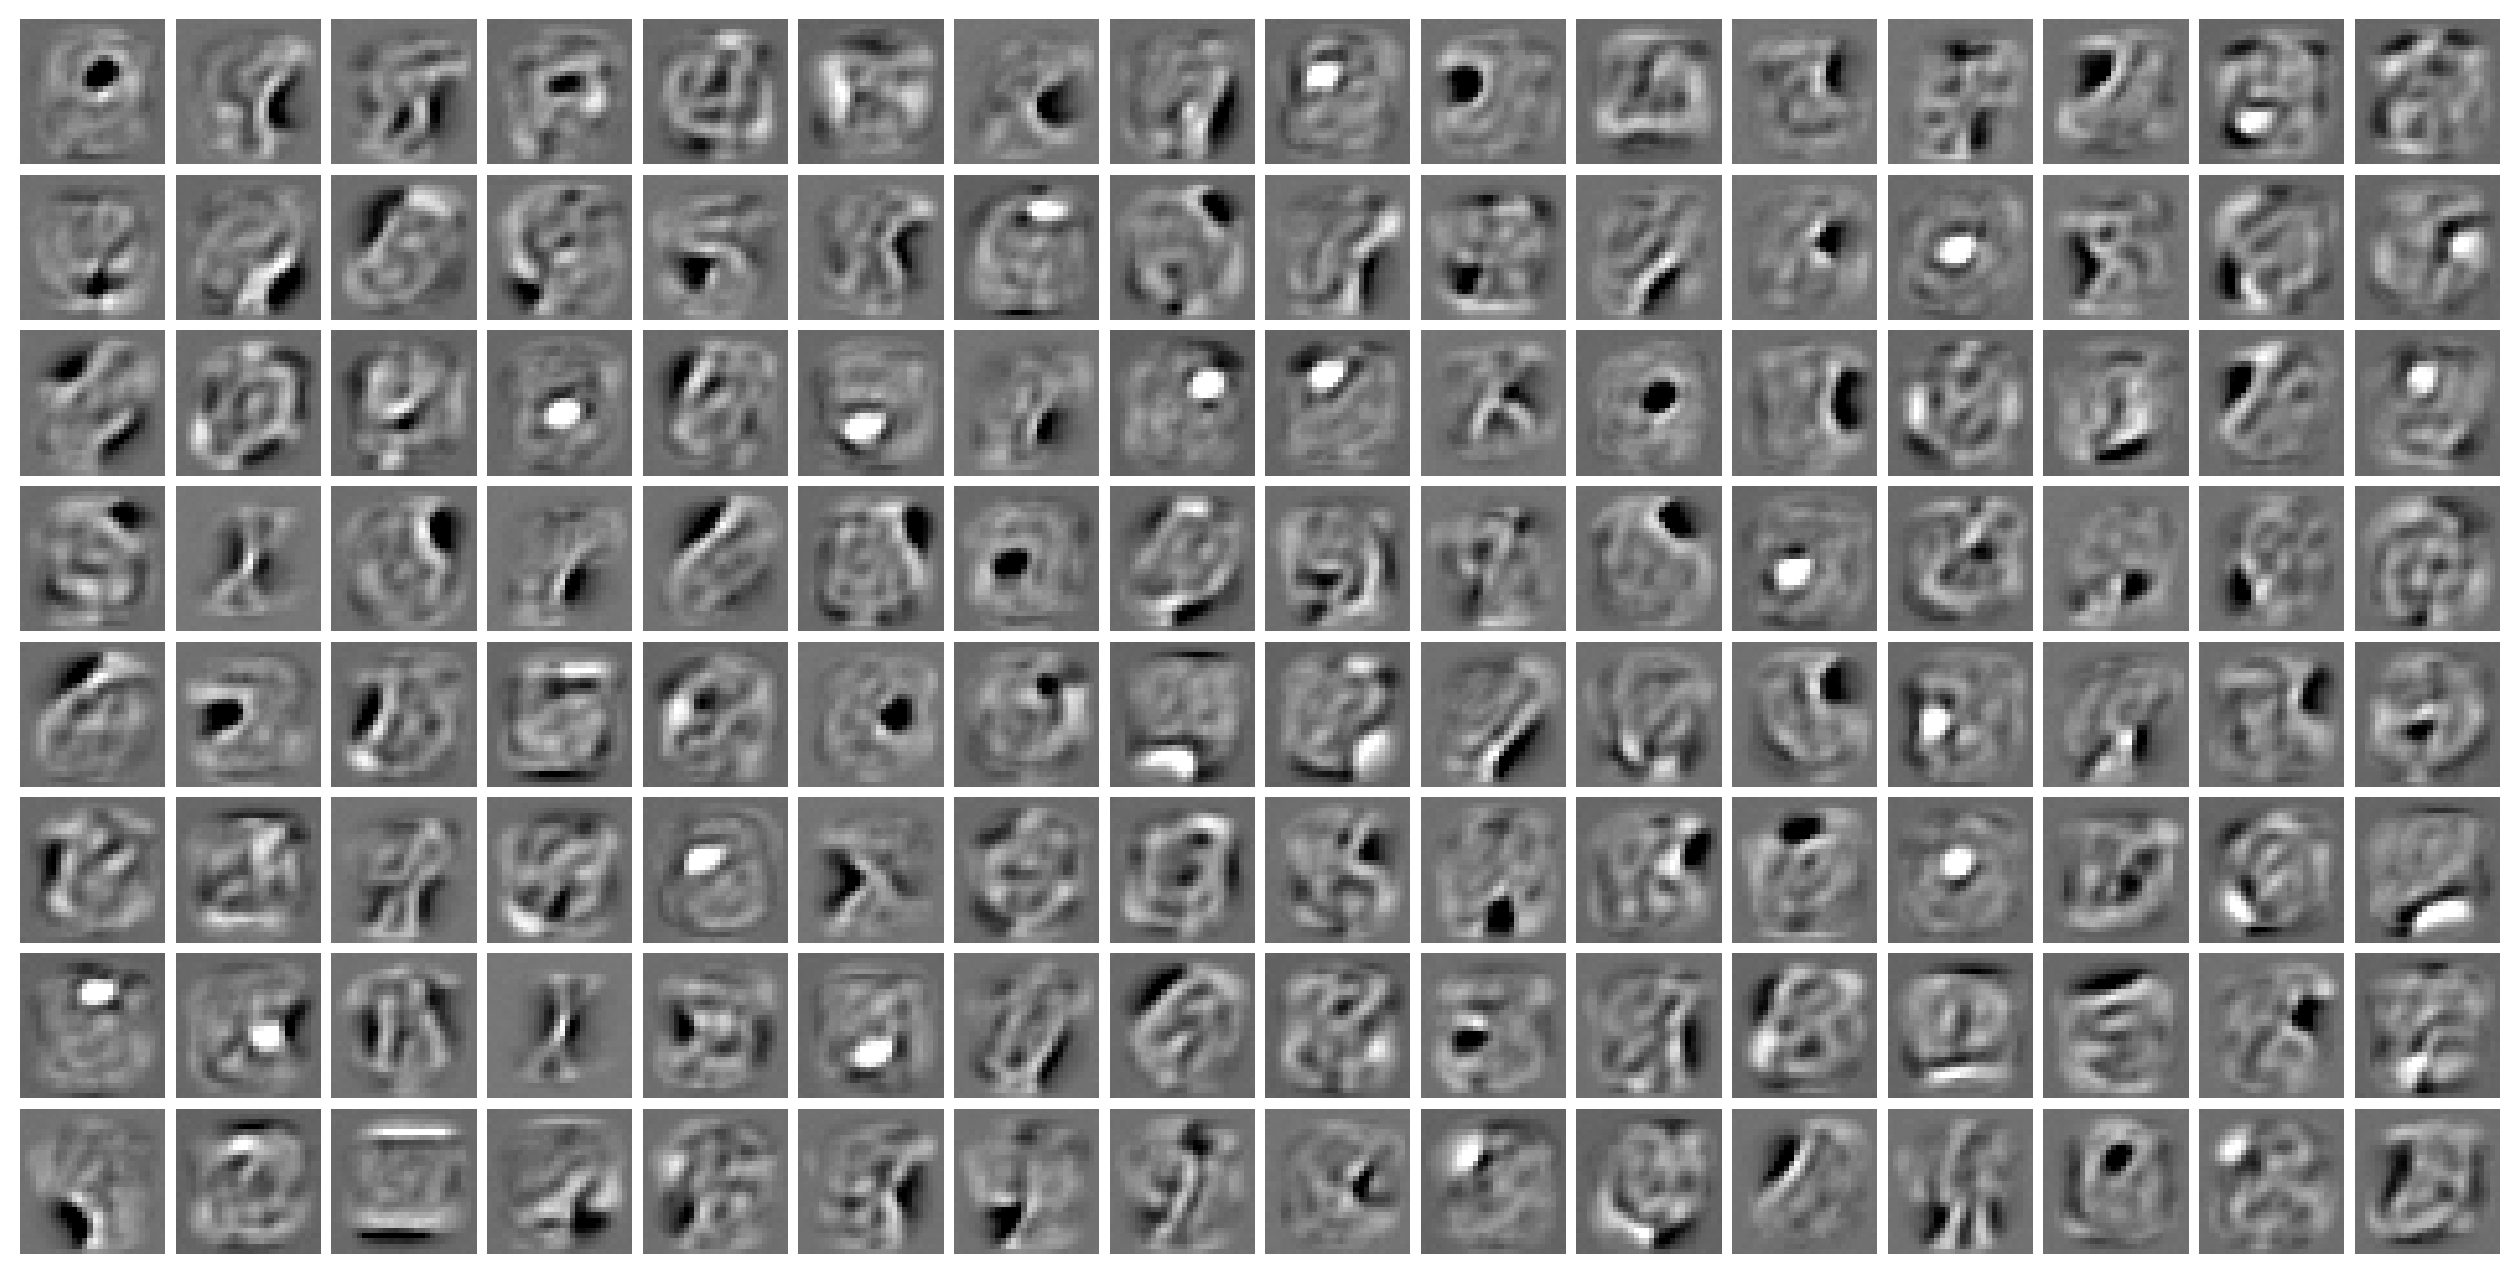

In [18]:
draw_filters(rbm_model)